# Régression logistique multiclasse
### Objectifs
L’objectif de ce travail est d’étudier et de mettre en œuvre un modèle de régression logistique multiclasse (softmax) pour des problèmes de classification comportant plus de deux classes. Plus précisément, nous chercherons à :

1. Définir et implémenter une fonction permettant d’entraîner un modèle de régression logistique multiclasse.

2. Utiliser la méthode de la descente de gradient pour optimiser les paramètres du classifieur.

3. Visualiser le comportement et les frontières de décision du modèle sur des données bidimensionnelles.

4. Tester différentes transformations de variables (feature transforms) afin d’analyser leur impact sur la performance et la séparation des classes.

Cette étude permettra de mieux comprendre le fonctionnement théorique et pratique du modèle softmax, ainsi que l’influence de la représentation des données sur la qualité de la classification.

 
 **Reference:**
 Section "4.3.4 Multiclass logistic regression"
 of

 C. M. Bishop *Pattern Recognition and Machine Learning*,
Information Science and Statistics, Springer, 2006

Freely available:
https://www.microsoft.com/en-us/research/people/cmbishop/prml-book/


In [61]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons, make_circles, make_classification, make_blobs, make_gaussian_quantiles
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Génération d’un jeu de données synthétique:

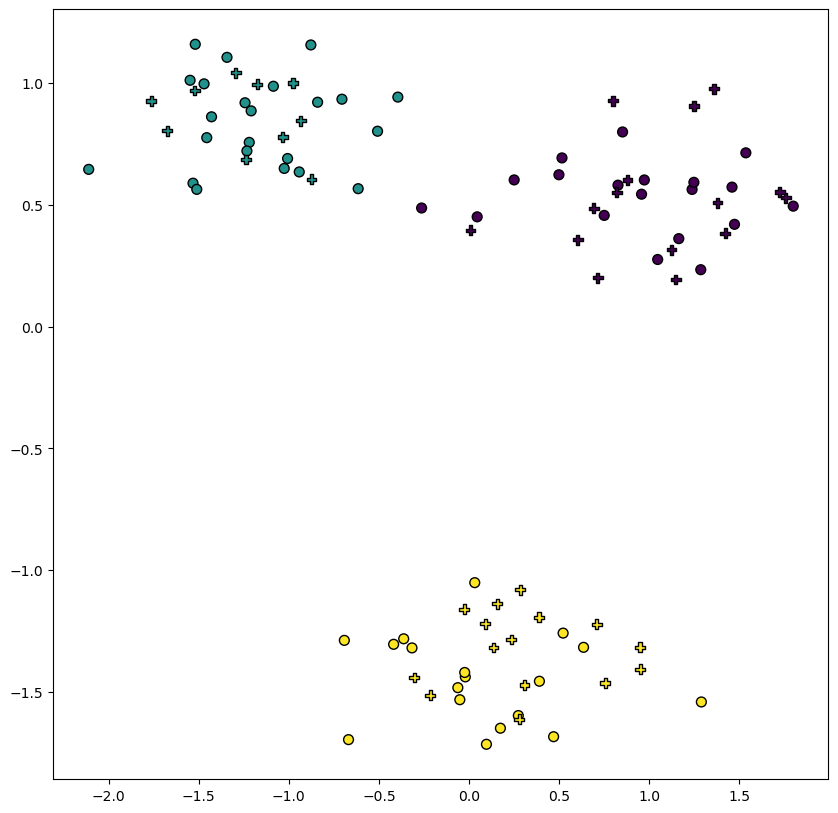

In [62]:
n_class = 3 # nombre de classe
# Trois exemples de jeux de données synthétiques en 2D :
X, t = make_blobs(n_features = 2, centers = n_class, n_samples = 100)
#X, t = make_classification(n_features=2, n_redundant=0, n_informative=2, random_state=24, n_classes=n_class, n_clusters_per_class=1,n_samples=200)
#X, t = make_gaussian_quantiles(n_features=2, n_classes=n_class, n_samples=500)

X = StandardScaler().fit_transform(X) # Normalisation pour avoir des colonne centrées réduites
X_train, X_test, t_train, t_test = train_test_split(X, t, test_size = .4, random_state = 12) 
# division de l'échantillon X et les classes t en deux echantillons aléatoire 
# d'entrainement et de test

# Nombre de points des échantillons
N_train = X_train.shape[0]
N_test = X_test.shape[0]

# Les echantillons d'entrainement et de test par classe (couleurs)
figure = plt.figure(figsize = (10, 10))
plt.scatter(X_train[:, 0], X_train[:, 1], marker = 'o', c = t_train, s = 50, edgecolor = 'k')
plt.scatter(X_test[:, 0], X_test[:, 1], marker = 'P', c = t_test, s = 50, edgecolor = 'k')
plt.show()



## Apply feature transform:


In [63]:
# Fonction qui permet d'augmenter le nombre de paramètre en ajoutant un paramètre de 1
# (i.e une colonne de 1 à la table x) prepare les données à un modèle linaire ajoute le biais
def identity(x):
  return(np.hstack((x, np.ones((x.shape[0],1)))))

# Transformation en ajoutant d'autres paramètres (pour des frontière en courbe quadratique)
def feat_transform_2D_prod(x):
  return np.hstack((x, x**2, (x[:,0]*x[:,1]).reshape((x.shape[0],1)), np.ones((x.shape[0],1))))

In [64]:
# faire le choix entre les deux transformations (on commence par l'identité)
feature_transform = identity
#feature_transform = feat_transform_2D_prod

Phi_train = feature_transform(X_train) # Applique la transformation des variables aux données train 
n_feat = Phi_train.shape[1] # Récupère le nombre de variables (colonnes) après transformation 
print('n_feat = ', n_feat) 
Phi_test = feature_transform(X_test) # Applique la même transformation aux données de test

n_feat =  3


<font color = 'yellow'> **Question de compréhention : ** Que fait le code ```np.ones((x.shape[0],1))``` ? A quoi cela correspond ? </font>
<font color = 'red'> **Réponse : **Crée une matrice colonne de 1 ayant autant de lignes que x ça correspond à un ajout de biais.

## Functions for Multiclass logistic regression:


In [65]:
# Définition de la fonction softmax
def soft_max(W, Phi): # - W est la matrice de taille n_feat x n_class
# évaluer le vecteur softmax pour une liste de points caractéristiques 
# phi (donné dans la ligne)
  if Phi.ndim == 1: 
    Phi = Phi.reshape((1, Phi.size)) # Une seule observation → vecteur ligne.
  a = Phi @ W # On calcule les scores bruts des individus pour chaque classe
  y = np.exp(a)
  s = np.sum(y, axis = 1)
  y = y/s.reshape((s.size, 1)) 
  return(y)

# Définition de la fonction de prédiction de la classe
def predicted_class(W,Phi):
  if Phi.ndim == 1: 
    Phi = Phi.reshape((1,Phi.size)) # Une seule observation → vecteur ligne.
  a = Phi @ W
  pred = np.argmax(a, axis = 1) # ça nous donne la classe 
  # # c'est equivalent à:
  # y = soft_max(W, Phi)
  # pred = np.argmax(y,axis=1)
  return(pred)

# La cross-entropy
def mloglikelihood(W, Phi, t):
  if Phi.ndim == 1: # Une seule observation → vecteur ligne.
    Phi = Phi.reshape((1, Phi.size))
  y = soft_max(W, Phi)
  y = y[np.arange(Phi.shape[0]), t]
  L = - np.sum(np.log(y))
  return(L)

# Définition du gradient de la cross-entropy
def gradmloglikelihood(W, Phi, t):
  if Phi.ndim == 1: # Une seule observation → vecteur ligne.
    Phi = Phi.reshape((1, Phi.size))
  y = soft_max(W, Phi)
  y[np.arange(Phi.shape[0]), t] = y[np.arange(Phi.shape[0]), t] - 1
  g = Phi.transpose() @ y
  return(g)

## Training with gradient descent on full dataset

n =  0  F(W) =  59.892782475595276
n =  0  F(W) =  32.7264914932518
n =  100  F(W) =  2.5041921193859
n =  200  F(W) =  1.9063284894151136
n =  300  F(W) =  1.6278510612077144
n =  400  F(W) =  1.4500239085804338
n =  500  F(W) =  1.3202596618681834
n =  600  F(W) =  1.2184678573112886
n =  700  F(W) =  1.1349833379992602
n =  800  F(W) =  1.0644442115610313
n =  900  F(W) =  1.0035697744733056


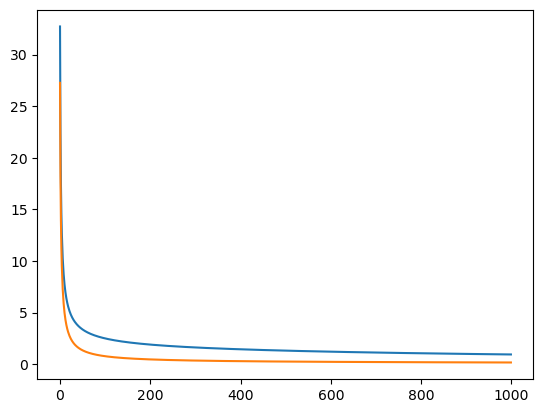

In [66]:
# initialisation aléatoire des poids :
W = np.random.rand(n_feat, n_class)

Loss = [] ################################
grad_norm = [] ################################


lr = 1/N_train
Nit = 10**3
print('n = ', 0, ' F(W) = ', mloglikelihood(W, Phi_train, t_train))
for n in range(Nit):
  W -= lr*gradmloglikelihood(W, Phi_train, t_train)
  #lr = learning rate, qui se traduit en 'taux d'apprentissage'

  Loss.append(mloglikelihood(W, Phi_train, t_train)) ################################
  grad_norm.append(np.linalg.norm(gradmloglikelihood(W, Phi_train, t_train))) 

  #pour calculer la norme: np.linalg.norm().


  if n%(100) == 0:
    print('n = ', n, ' F(W) = ', mloglikelihood(W, Phi_train, t_train))


plt.plot(Loss)################################
plt.plot(grad_norm)################################
plt.show()

La variable "lr" correspond au learning rate, c’est-à-dire la taille du pas utilisé par l’algorithme pour mettre à jour les paramètres du modèle. Dans la section suivante, nous testerons différentes valeurs de "lr" afin d’évaluer leur impact sur les performances du modèle, en cherchant notamment à réduire la loss.

In [67]:
# Grille de learning rates
lr = np.linspace(1/100, 1/10, 1000)
Nit = 10**3
# Initialisation
loss = []
grad_norm = []
W_best = None
loss_min = float('inf')  # perte minimale initialisée à l'infini

for i in range(len(lr)):
    W_temp = W.copy()  # on copie W pour chaque lr
    for j in range(Nit):
        W_temp -= lr[i] * gradmloglikelihood(W_temp, Phi_train, t_train)
    
    # Calcul de la loss et de la norme du gradient
    current_loss = mloglikelihood(W_temp, Phi_train, t_train)
    current_grad_norm = np.linalg.norm(gradmloglikelihood(W_temp, Phi_train, t_train))
    
    loss.append(current_loss)
    grad_norm.append(current_grad_norm)
    
    # Si cette loss est la plus petite, on garde W_temp
    if current_loss < loss_min:
        loss_min = current_loss
        W_best = W_temp.copy()

print("Loss minimale:", loss_min)
print("W correspondant à la loss minimale:", W_best)

Loss minimale: 0.23875348568743224
W correspondant à la loss minimale: [[ 6.86365489 -7.29430575  3.03222643]
 [ 0.88880306  8.0343438  -7.78399274]
 [ 4.51648056 -4.72286893  1.71383195]]


## Classifier prediction:

In [68]:
print(W_best.shape)
print(Phi_test.shape)

pred = predicted_class(W_best, Phi_test)


print('pred: ', pred[:30])
print('true: ', t_test[:30])


(3, 3)
(40, 3)
pred:  [2 1 2 2 0 1 0 2 1 0 1 0 0 2 0 2 2 1 0 0 2 1 1 2 0 1 2 2 0 2]
true:  [2 1 2 2 0 1 0 2 1 0 1 0 0 2 0 2 2 1 0 0 2 1 1 2 0 1 2 2 0 2]


## Visualize classifiction regions:


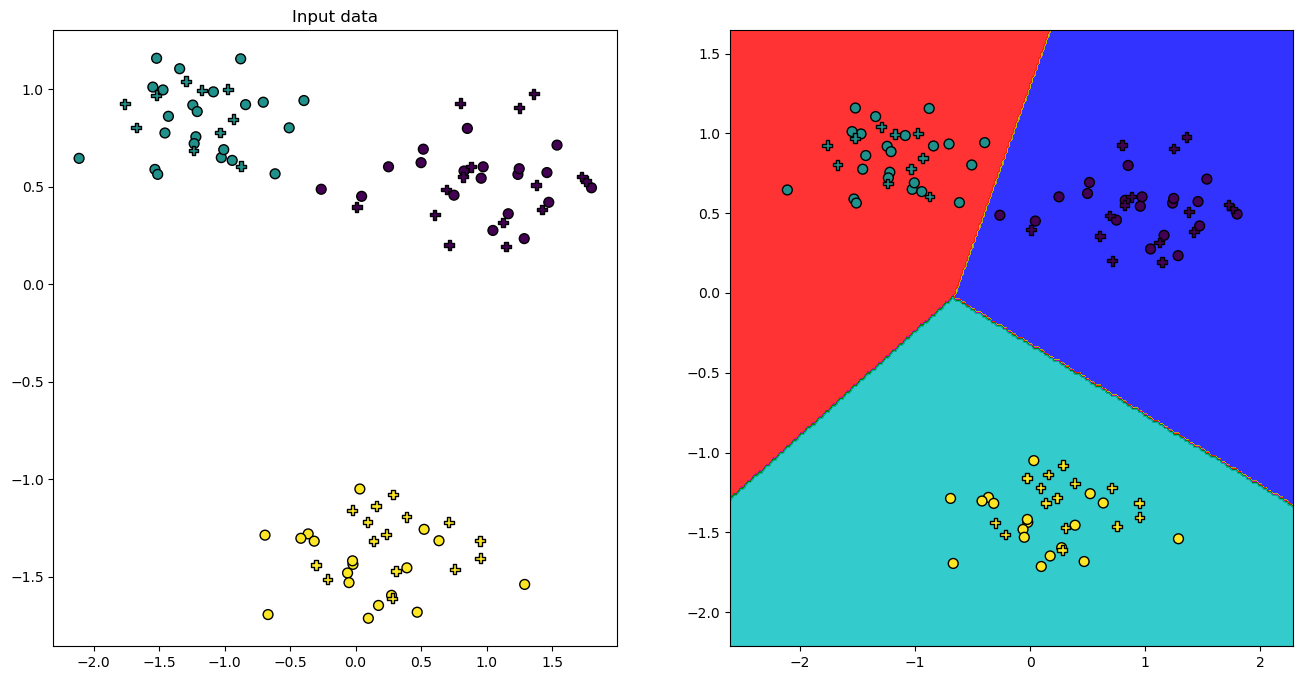

In [69]:
# visualisation des resultats:
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
h = 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))
X_grid = np.hstack((xx.ravel(), yy.ravel()))

N_grid = xx.ravel().shape[0]
X_grid = np.c_[xx.ravel(), yy.ravel()]
Phi_grid = feature_transform(X_grid)

Z = predicted_class(W_best, Phi_grid)
Z = Z.reshape(xx.shape)

figure = plt.figure(figsize=(16, 8))
ax = plt.subplot(1,2,1)
ax.set_title("Input data")
ax.scatter(X_train[:, 0], X_train[:, 1], marker='o', c=t_train, s=50, edgecolor='k')
ax.scatter(X_test[:, 0], X_test[:, 1], marker='P', c=t_test, s=50, edgecolor='k')
ax = plt.subplot(1,2,2)
cmap = ListedColormap(['b','y','r','m','g','c'])
plt.contourf(xx,yy,Z,  cmap = cmap, alpha=.8)
ax.scatter(X_train[:, 0], X_train[:, 1], marker='o', c=t_train, s=50, edgecolor='k')
ax.scatter(X_test[:, 0], X_test[:, 1], marker='P', c=t_test, s=50, edgecolor='k')


## Classifier performance:
  <font color='yellow'>
Evaluation des performances du classifieur en utilisant les fonctions ci-dessous :</font>

```
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
```

In [70]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [71]:
y_true = t_test # les classes des données de tests (X_test[0] appartient à la classe y_true[0])
y_pred = predicted_class(W_best, Phi_test) # les classes prédites des données de tests par nos poids W
target_names = ['class 0', 'class 1', 'class 2']
print(classification_report(y_true, y_pred, target_names = target_names))

              precision    recall  f1-score   support

     class 0       1.00      1.00      1.00        15
     class 1       1.00      1.00      1.00        10
     class 2       1.00      1.00      1.00        15

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



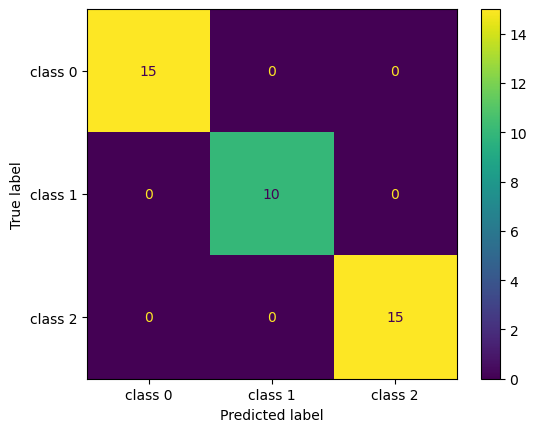

In [72]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = target_names)
disp.plot()
plt.show()

## Importance of feature transform:

Dans cette section, nous étudions les performances d’un classificateur sur le jeu de données gaussian_quantiles en comparant différentes transformations de caractéristiques :

- Transformation identité (identity) : tester le classificateur sans modifier les caractéristiques et analyser les résultats obtenus.

- Transformation non linéaire (feat_transform_2D_prod) : appliquer une combinaison simple des caractéristiques pour observer l’impact sur les performances du classificateur.

- Transformation inspirée d’une couche cachée de réseau de neurones : définir une couche linéaire avec 25 neurones, où chaque neurone applique une combinaison linéaire aléatoire des entrées suivie d’une activation ReLU. Les poids et biais sont tirés indépendamment d’une distribution gaussienne standard et restent fixes pour tous les points de données. Cette étape permet d’évaluer comment une transformation non linéaire plus riche peut améliorer la séparation des données.

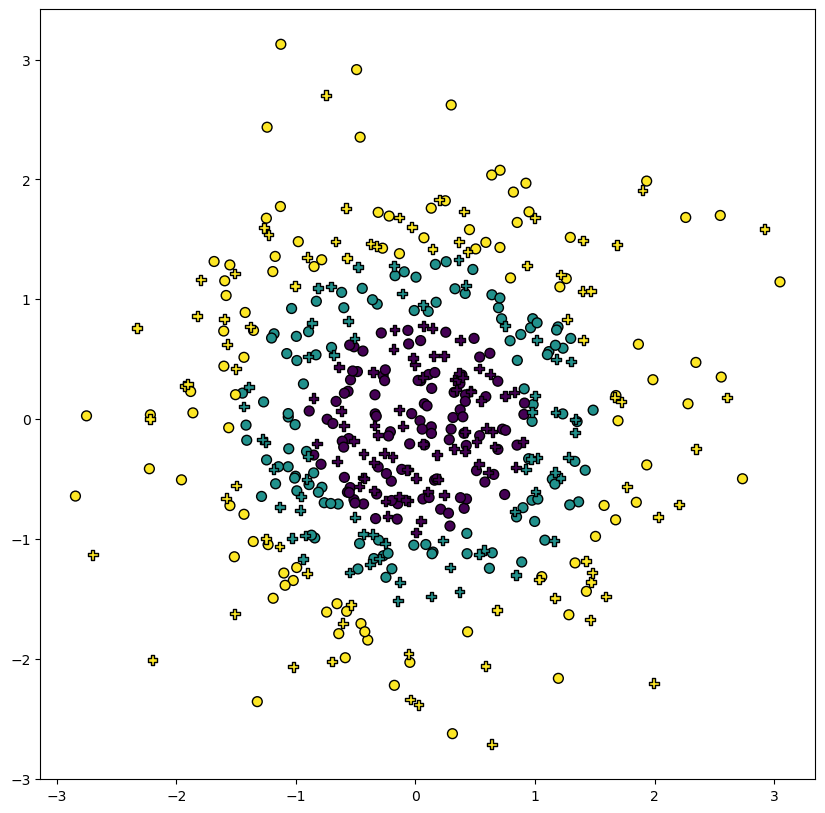

In [73]:
n_class = 3 # nombre de classe
X, t = make_gaussian_quantiles(n_features = 2, n_classes = n_class, n_samples = 500)
X = StandardScaler().fit_transform(X) # Normalisation pour avoir des colonne centrées réduites
X_train, X_test, t_train, t_test = train_test_split(X, t, test_size = .4, random_state = 12) 
# division de l'échantillon X et les classes t en deux echantillons aléatoire 
# d'entrainement et de test

# Nombre de points des échantillons
N_train = X_train.shape[0]
N_test = X_test.shape[0]

# Les echantillons d'entrainement et de test par classe (couleurs)
figure = plt.figure(figsize = (10, 10))
plt.scatter(X_train[:, 0], X_train[:, 1], marker = 'o', c = t_train, s = 50, edgecolor = 'k')
plt.scatter(X_test[:, 0], X_test[:, 1], marker = 'P', c = t_test, s = 50, edgecolor = 'k')
plt.show()

In [74]:
# avec la transformation identité
feature_transform = identity
Phi_train = feature_transform(X_train) # Applique la transformation des variables aux données 
n_feat = Phi_train.shape[1] # Récupère le nombre de variables (colonnes) après transformation 
print('n_feat = ', n_feat) 
Phi_test = feature_transform(X_test) # Applique la même transformation aux données de test

n_feat =  3


n =  0  F(W) =  335.53973614489007
n =  0  F(W) =  330.53670569500275
n =  100  F(W) =  325.7842680204352
n =  200  F(W) =  325.7842680204352
n =  300  F(W) =  325.7842680204352
n =  400  F(W) =  325.7842680204352
n =  500  F(W) =  325.7842680204352
n =  600  F(W) =  325.7842680204352
n =  700  F(W) =  325.7842680204352
n =  800  F(W) =  325.7842680204352
n =  900  F(W) =  325.7842680204352


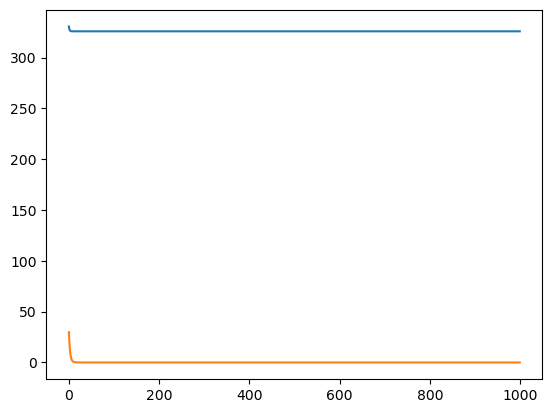

In [75]:
# initialisation aléatoire des poids :
W = np.random.rand(n_feat, n_class)

Loss = [] ################################
grad_norm = [] ################################


lr = 1/N_train
Nit = 10**3
print('n = ', 0, ' F(W) = ', mloglikelihood(W, Phi_train, t_train))
for n in range(Nit):
  W -= lr*gradmloglikelihood(W, Phi_train, t_train)
  #lr = learning rate, qui se traduit en 'taux d'apprentissage'

  Loss.append(mloglikelihood(W, Phi_train, t_train)) ################################
  grad_norm.append(np.linalg.norm(gradmloglikelihood(W, Phi_train, t_train))) 

  #pour calculer la norme: np.linalg.norm().


  if n%(100) == 0:
    print('n = ', n, ' F(W) = ', mloglikelihood(W, Phi_train, t_train))


plt.plot(Loss)################################
plt.plot(grad_norm)################################
plt.show()

In [76]:
# Grille de learning rates
lr = np.linspace(1/100, 1/10, 1000)
Nit = 10**3
# Initialisation
loss = []
grad_norm = []
W_best = None
loss_min = float('inf')  # perte minimale initialisée à l'infini

for i in range(len(lr)):
    W_temp = W.copy()  # on copie W pour chaque lr
    for j in range(Nit):
        W_temp -= lr[i] * gradmloglikelihood(W_temp, Phi_train, t_train)
    
    # Calcul de la loss et de la norme du gradient
    current_loss = mloglikelihood(W_temp, Phi_train, t_train)
    current_grad_norm = np.linalg.norm(gradmloglikelihood(W_temp, Phi_train, t_train))
    
    loss.append(current_loss)
    grad_norm.append(current_grad_norm)
    
    # Si cette loss est la plus petite, on garde W_temp
    if current_loss < loss_min:
        loss_min = current_loss
        W_best = W_temp.copy()

print("Loss minimale:", loss_min)
print("W correspondant à la loss minimale:", W_best)

Loss minimale: 325.7842680204352
W correspondant à la loss minimale: [[0.41667707 0.41629753 0.30749998]
 [0.16044551 0.24473547 0.52109212]
 [0.75175886 0.83399192 0.69659143]]


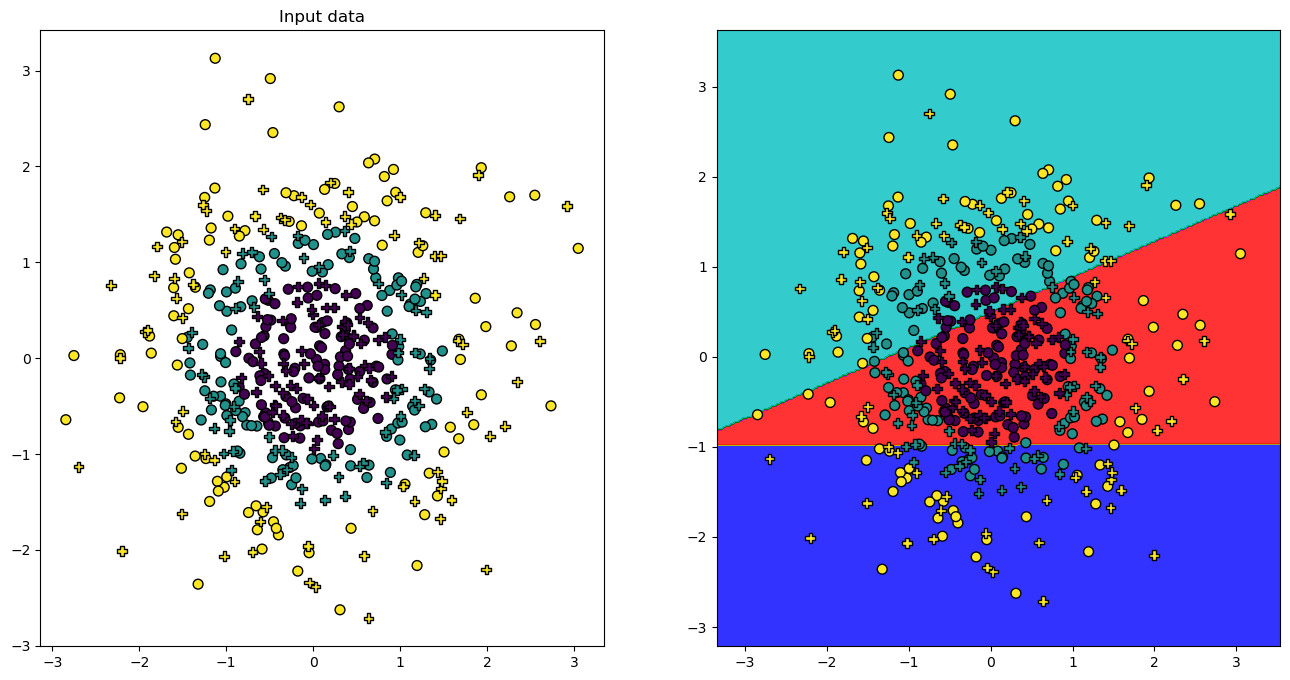

In [77]:
#visualize results:
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
h = 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))
X_grid = np.hstack((xx.ravel(), yy.ravel()))

N_grid = xx.ravel().shape[0]
X_grid = np.c_[xx.ravel(), yy.ravel()]
Phi_grid = feature_transform(X_grid)

Z = predicted_class(W,Phi_grid)
Z = Z.reshape(xx.shape)

figure = plt.figure(figsize=(16, 8))
ax = plt.subplot(1,2,1)
ax.set_title("Input data")
ax.scatter(X_train[:, 0], X_train[:, 1], marker='o', c=t_train, s=50, edgecolor='k')
ax.scatter(X_test[:, 0], X_test[:, 1], marker='P', c=t_test, s=50, edgecolor='k')
ax = plt.subplot(1,2,2)
cmap = ListedColormap(['b','y','r','m','g','c'])
plt.contourf(xx,yy,Z,  cmap = cmap, alpha=.8)
ax.scatter(X_train[:, 0], X_train[:, 1], marker='o', c=t_train, s=50, edgecolor='k')
ax.scatter(X_test[:, 0], X_test[:, 1], marker='P', c=t_test, s=50, edgecolor='k')

Il apparaît clairement que l’utilisation d’une transformation linéaire est peu adaptée pour classifier des données dont la distribution est elliptique et gaussienne.

Pour la suite, nous privilégierons l’utilisation d’une transformation non linéaire afin d’améliorer la classification de ces données.

In [78]:
feature_transform = feat_transform_2D_prod
Phi_train = feature_transform(X_train) # Applique la transformation des variables aux données train 
n_feat = Phi_train.shape[1] # Récupère le nombre de variables (colonnes) après transformation 
print('n_feat = ', n_feat) 
Phi_test = feature_transform(X_test) # Applique la même transformation aux données de test

n_feat =  6


n =  0  F(W) =  349.1478939586283
n =  0  F(W) =  297.41746895393993
n =  100  F(W) =  85.71094843069503
n =  200  F(W) =  63.60037673739122
n =  300  F(W) =  53.23137841080366
n =  400  F(W) =  46.92300278032775
n =  500  F(W) =  42.56962575492379
n =  600  F(W) =  39.33069105315782
n =  700  F(W) =  36.79709936508914
n =  800  F(W) =  34.74307168055166
n =  900  F(W) =  33.03258652777858


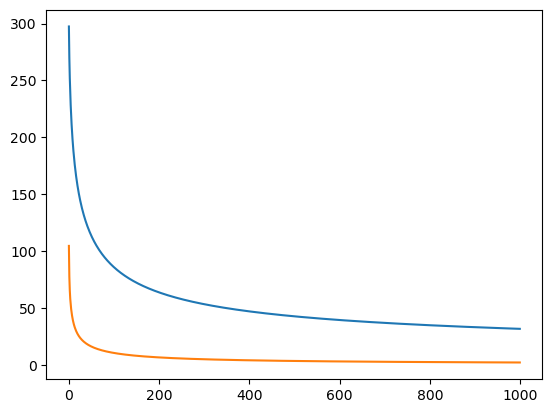

In [79]:
# initialisation aléatoire des poids :
W = np.random.rand(n_feat, n_class)

Loss = [] ################################
grad_norm = [] ################################


lr = 1/N_train
Nit = 10**3
print('n = ', 0, ' F(W) = ', mloglikelihood(W, Phi_train, t_train))
for n in range(Nit):
  W -= lr*gradmloglikelihood(W, Phi_train, t_train)
  #lr = learning rate, qui se traduit en 'taux d'apprentissage'

  Loss.append(mloglikelihood(W, Phi_train, t_train)) ################################
  grad_norm.append(np.linalg.norm(gradmloglikelihood(W, Phi_train, t_train))) 

  #pour calculer la norme: np.linalg.norm().


  if n%(100) == 0:
    print('n = ', n, ' F(W) = ', mloglikelihood(W, Phi_train, t_train))


plt.plot(Loss)################################
plt.plot(grad_norm)################################
plt.show()

In [80]:
# Grille de learning rates
lr = np.linspace(1/100, 1/10, 1000)
Nit = 10**3
# Initialisation
loss = []
grad_norm = []
W_best = None
loss_min = float('inf')  # perte minimale initialisée à l'infini

for i in range(len(lr)):
    W_temp = W.copy()  # on copie W pour chaque lr
    for j in range(Nit):
        W_temp -= lr[i] * gradmloglikelihood(W_temp, Phi_train, t_train)
    
    # Calcul de la loss et de la norme du gradient
    current_loss = mloglikelihood(W_temp, Phi_train, t_train)
    current_grad_norm = np.linalg.norm(gradmloglikelihood(W_temp, Phi_train, t_train))
    
    loss.append(current_loss)
    grad_norm.append(current_grad_norm)
    
    # Si cette loss est la plus petite, on garde W_temp
    if current_loss < loss_min:
        loss_min = current_loss
        W_best = W_temp.copy()

print("Loss minimale:", loss_min)
print("W correspondant à la loss minimale:", W_best)

Loss minimale: 4.126053160925856
W correspondant à la loss minimale: [[  1.92312081   0.78681591  -1.44041152]
 [ -3.38226309   0.64946564   4.6408693 ]
 [-28.97368173   4.94759951  25.68322   ]
 [-31.60775493   3.94335837  28.11534264]
 [ -2.25914985   0.85573878   2.63114227]
 [ 36.77093338   7.21380944 -42.72468934]]


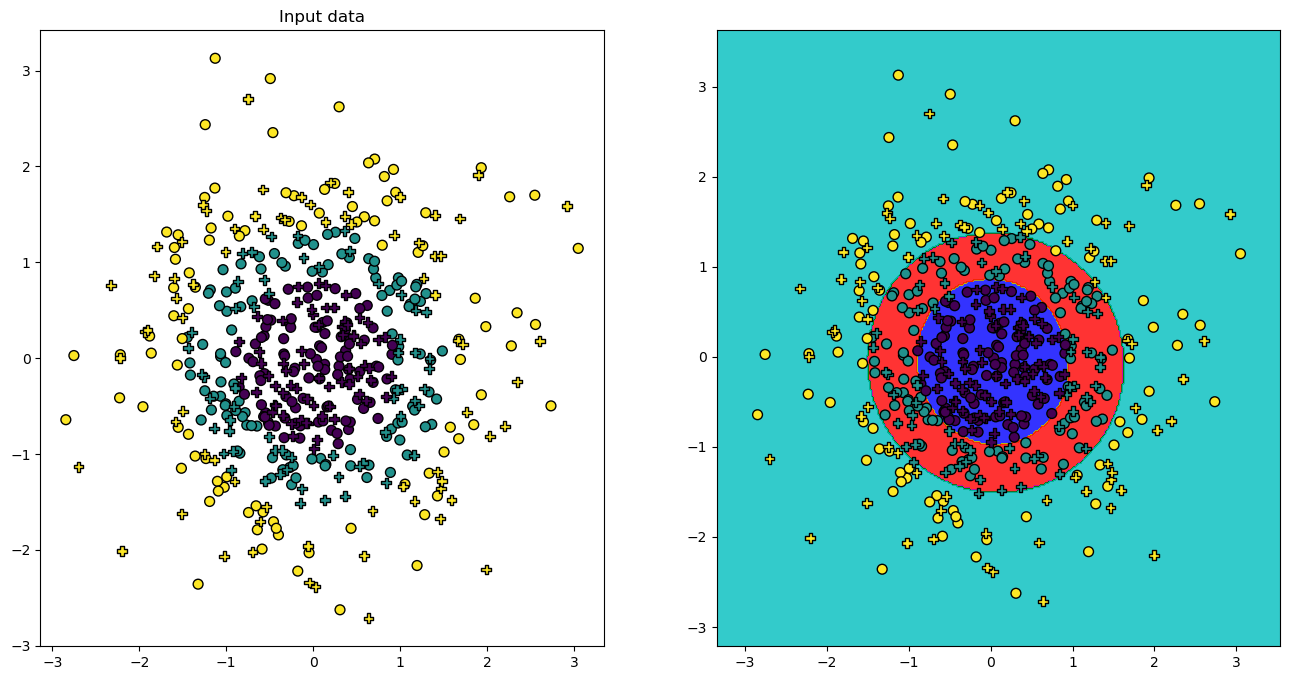

In [81]:
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
h = 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))
X_grid = np.hstack((xx.ravel(), yy.ravel()))

N_grid = xx.ravel().shape[0]
X_grid = np.c_[xx.ravel(), yy.ravel()]
Phi_grid = feature_transform(X_grid)

Z = predicted_class(W,Phi_grid)
Z = Z.reshape(xx.shape)

figure = plt.figure(figsize=(16, 8))
ax = plt.subplot(1,2,1)
ax.set_title("Input data")
ax.scatter(X_train[:, 0], X_train[:, 1], marker='o', c=t_train, s=50, edgecolor='k')
ax.scatter(X_test[:, 0], X_test[:, 1], marker='P', c=t_test, s=50, edgecolor='k')
ax = plt.subplot(1,2,2)
cmap = ListedColormap(['b','y','r','m','g','c'])
plt.contourf(xx,yy,Z,  cmap = cmap, alpha=.8)
ax.scatter(X_train[:, 0], X_train[:, 1], marker='o', c=t_train, s=50, edgecolor='k')
ax.scatter(X_test[:, 0], X_test[:, 1], marker='P', c=t_test, s=50, edgecolor='k')

In [82]:
y_true = t_test # les classes des données de tests (X_test[0] appartient à la classe y_true[0])
y_pred = predicted_class(W_best, Phi_test) # les classes prédites des données de tests par nos poids W
target_names = ['class 0', 'class 1', 'class 2']
print(classification_report(y_true, y_pred, target_names = target_names))

              precision    recall  f1-score   support

     class 0       0.97      1.00      0.99        68
     class 1       1.00      0.92      0.96        60
     class 2       0.96      1.00      0.98        72

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200



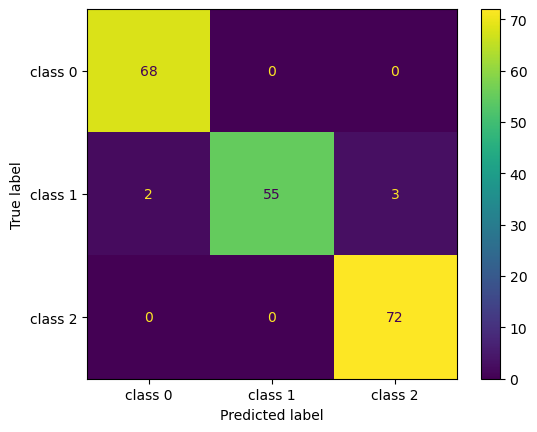

In [83]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = target_names)
disp.plot()
plt.show()

  <font color='yellow'> **section**: Proposition  d'une tranformation en "features" pour le troisième "dataset" (```make_classification```).</font>

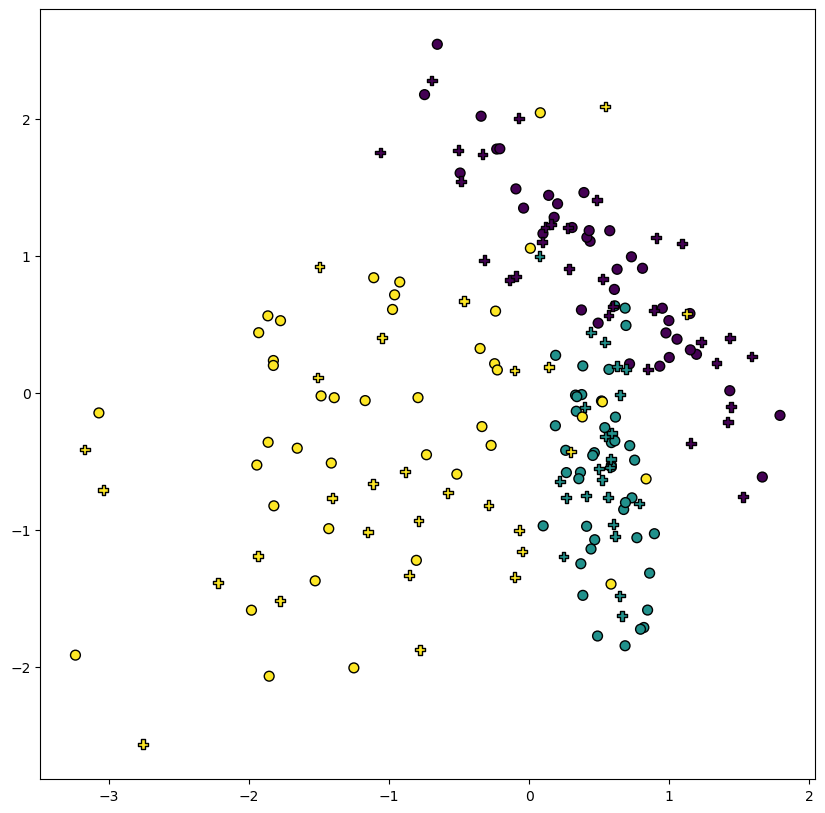

In [84]:
n_class = 3 # nombre de classe

X, t = make_classification(n_features = 2, n_redundant = 0, n_informative = 2, 
                           random_state = 24, n_classes=n_class, n_clusters_per_class=1,n_samples=200)

X = StandardScaler().fit_transform(X) # Normalisation pour avoir des colonne centrées réduites
X_train, X_test, t_train, t_test = train_test_split(X, t, test_size = .4, random_state = 12) 
# division de l'échantillon X et les classes t en deux echantillons aléatoire 
# d'entrainement et de test

# Nombre de points des échantillons
N_train = X_train.shape[0]
N_test = X_test.shape[0]

# Les echantillons d'entrainement et de test par classe (couleurs)
figure = plt.figure(figsize = (10, 10))
plt.scatter(X_train[:, 0], X_train[:, 1], marker = 'o', c = t_train, s = 50, edgecolor = 'k')
plt.scatter(X_test[:, 0], X_test[:, 1], marker = 'P', c = t_test, s = 50, edgecolor = 'k')
plt.show()

In [85]:
feature_transform = feat_transform_2D_prod
Phi_train = feature_transform(X_train) # Applique la transformation des variables aux données train 
n_feat = Phi_train.shape[1] # Récupère le nombre de variables (colonnes) après transformation 
print('n_feat = ', n_feat) 
Phi_test = feature_transform(X_test) # Applique la même transformation aux données de test

n_feat =  6


n =  0  F(W) =  201.81189233247608
n =  0  F(W) =  103.67836238305122
n =  100  F(W) =  35.67760017288434
n =  200  F(W) =  33.74086843221433
n =  300  F(W) =  32.7167467623414
n =  400  F(W) =  31.984425104952294
n =  500  F(W) =  31.41286456624319
n =  600  F(W) =  30.948793394755278
n =  700  F(W) =  30.56270363949572
n =  800  F(W) =  30.235730522522267
n =  900  F(W) =  29.954886286295178


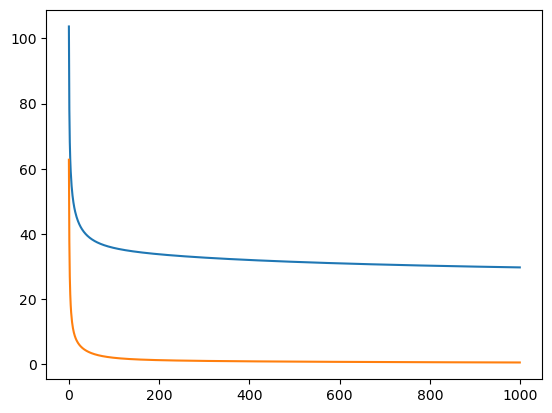

In [86]:
# initialisation aléatoire des poids :
W = np.random.rand(n_feat, n_class)

Loss = [] ################################
grad_norm = [] ################################


lr = 1/N_train
Nit = 10**3
print('n = ', 0, ' F(W) = ', mloglikelihood(W, Phi_train, t_train))
for n in range(Nit):
  W -= lr*gradmloglikelihood(W, Phi_train, t_train)
  #lr = learning rate, qui se traduit en 'taux d'apprentissage'

  Loss.append(mloglikelihood(W, Phi_train, t_train)) ################################
  grad_norm.append(np.linalg.norm(gradmloglikelihood(W, Phi_train, t_train))) 

  #pour calculer la norme: np.linalg.norm().


  if n%(100) == 0:
    print('n = ', n, ' F(W) = ', mloglikelihood(W, Phi_train, t_train))


plt.plot(Loss)################################
plt.plot(grad_norm)################################
plt.show()

In [87]:
# Grille de learning rates
lr = np.linspace(1/100, 1/10, 1000)
Nit = 10**3
# Initialisation
loss = []
grad_norm = []
W_best = None
loss_min = float('inf')  # perte minimale initialisée à l'infini

for i in range(len(lr)):
    W_temp = W.copy()  # on copie W pour chaque lr
    for j in range(Nit):
        W_temp -= lr[i] * gradmloglikelihood(W_temp, Phi_train, t_train)
    
    # Calcul de la loss et de la norme du gradient
    current_loss = mloglikelihood(W_temp, Phi_train, t_train)
    current_grad_norm = np.linalg.norm(gradmloglikelihood(W_temp, Phi_train, t_train))
    
    loss.append(current_loss)
    grad_norm.append(current_grad_norm)
    
    # Si cette loss est la plus petite, on garde W_temp
    if current_loss < loss_min:
        loss_min = current_loss
        W_best = W_temp.copy()

print("Loss minimale:", loss_min)
print("W correspondant à la loss minimale:", W_best)

Loss minimale: 26.820800425569985
W correspondant à la loss minimale: [[ 6.43587267  2.95357018 -7.65460285]
 [12.72605812 -6.71367586 -3.88537936]
 [ 3.43650206 -4.90958773  3.24740103]
 [-3.05946791  2.41218701  2.57664506]
 [-7.81992467  6.08977057  2.717072  ]
 [-5.80384604  2.99701119  3.90737717]]


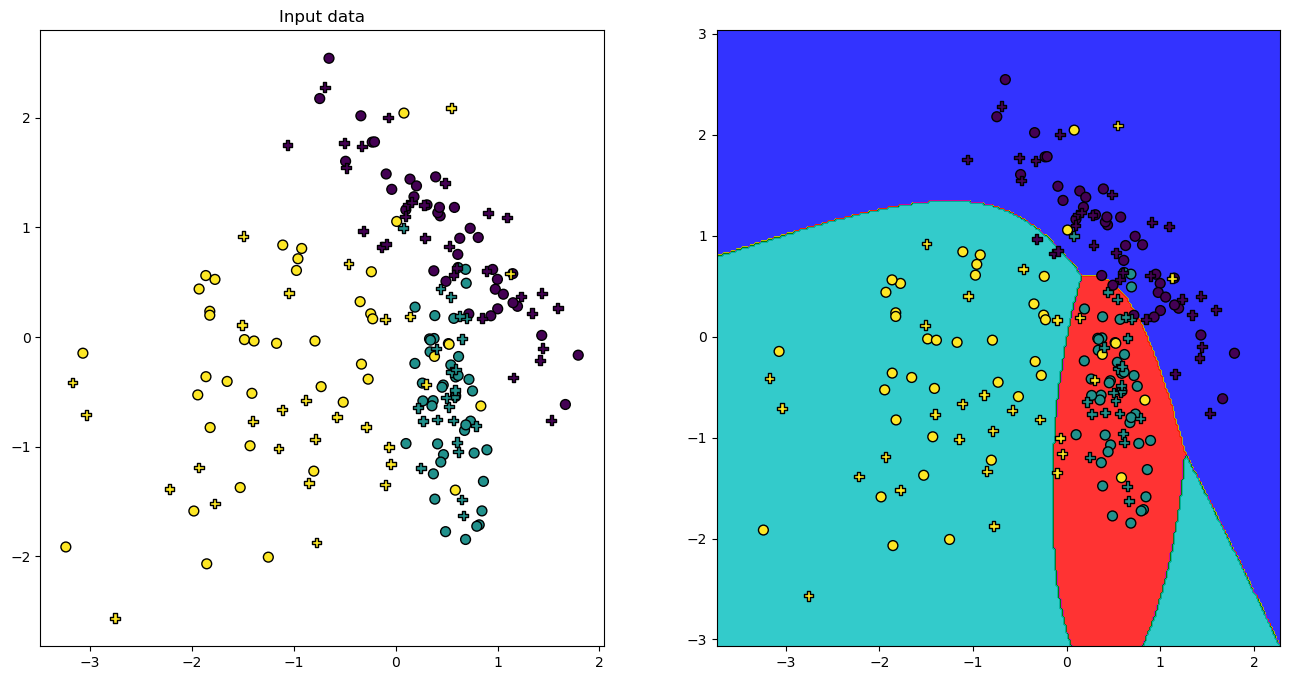

In [88]:
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
h = 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))
X_grid = np.hstack((xx.ravel(), yy.ravel()))

N_grid = xx.ravel().shape[0]
X_grid = np.c_[xx.ravel(), yy.ravel()]
Phi_grid = feature_transform(X_grid)

Z = predicted_class(W,Phi_grid)
Z = Z.reshape(xx.shape)

figure = plt.figure(figsize=(16, 8))
ax = plt.subplot(1,2,1)
ax.set_title("Input data")
ax.scatter(X_train[:, 0], X_train[:, 1], marker='o', c=t_train, s=50, edgecolor='k')
ax.scatter(X_test[:, 0], X_test[:, 1], marker='P', c=t_test, s=50, edgecolor='k')
ax = plt.subplot(1,2,2)
cmap = ListedColormap(['b','y','r','m','g','c'])
plt.contourf(xx,yy,Z,  cmap = cmap, alpha=.8)
ax.scatter(X_train[:, 0], X_train[:, 1], marker='o', c=t_train, s=50, edgecolor='k')
ax.scatter(X_test[:, 0], X_test[:, 1], marker='P', c=t_test, s=50, edgecolor='k')

In [89]:
y_true = t_test # les classes des données de tests (X_test[0] appartient à la classe y_true[0])
y_pred = predicted_class(W_best, Phi_test) # les classes prédites des données de tests par nos poids W
target_names = ['class 0', 'class 1', 'class 2']
print(classification_report(y_true, y_pred, target_names = target_names))

              precision    recall  f1-score   support

     class 0       0.93      0.90      0.92        30
     class 1       0.85      0.96      0.90        23
     class 2       0.88      0.81      0.85        27

    accuracy                           0.89        80
   macro avg       0.89      0.89      0.89        80
weighted avg       0.89      0.89      0.89        80



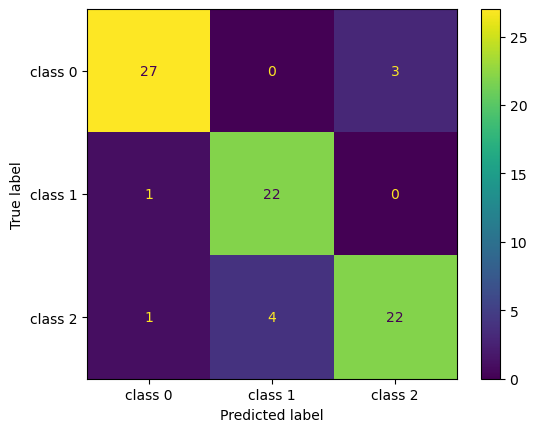

In [90]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = target_names)
disp.plot()
plt.show()